# CMIP5 vs CMIP6: Combined Urban Precipitation Analysis

| | CMIP5 | CMIP6 |
|---|---|---|
| Scenario | RCP 8.5 | SSP 8.5 |
| Extreme index | Rx1day | Rx1day (+ Rx5day) |
| Classification | 4 categories | 4 categories |

**Sections:** 1. CMIP5 | 2. CMIP6 | 3. Comparison


In [30]:
import os
import numpy as np
import pandas as pd
import rasterio
import rasterio.features
import rasterio.transform
import rasterio.windows
from rasterio.transform import from_origin
from shapely.geometry import shape, mapping
import geopandas as gpd
from pyproj import Transformer
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display

mpl.rcParams.update({
    'font.size': 14, 'axes.titlesize': 15,
    'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12
})

CONSENSUS_THRESHOLD = 0.6

# CMIP5 paths (RCP 8.5)
CMIP5_PATH_RX1DAY     = r"D:\Development\RESEARCH\Raanana\data\CMIP5\RCP_8_5\rx1day\map.nc"
CMIP5_PATH_TOTAL      = r"D:\Development\RESEARCH\Raanana\data\CMIP5\RCP_8_5\total_prec\map.nc"
CMIP5_PATH_CON_RX1DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP5\RCP_8_5\rx1day\consensus.nc"
CMIP5_PATH_CON_TOTAL  = r"D:\Development\RESEARCH\Raanana\data\CMIP5\RCP_8_5\total_prec\consensus.nc"

# CMIP6 paths (SSP 8.5)
CMIP6_PATH_RX1DAY     = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_1day_prec\map.nc"
CMIP6_PATH_RX5DAY     = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_5day_prec\map.nc"
CMIP6_PATH_TOTAL      = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\total_prec\map.nc"
CMIP6_PATH_CON_RX1DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_1day_prec\consensus.nc"
CMIP6_PATH_CON_RX5DAY = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\max_5day_prec\consensus.nc"
CMIP6_PATH_CON_TOTAL  = r"D:\Development\RESEARCH\Raanana\data\CMIP6\ssp_8_5\total_prec\consensus.nc"

# Urban raster
URBAN_RASTER_PATH = r"D:\Development\RESEARCH\Raanana\data\esa_worldcover\GHS_BUILT_S_E2020_GLOBE_R2023A_54009_1000_V1_0.tif"
URBAN_THRESHOLD   = 38
RASTER_BLOCK_SIZE = 1024
MOLLWEIDE_CRS = "+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

# Publication output directory
OUT_DIR = r"D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures"

# Colorblind-safe palette: Cat1=orange, Cat2=RED (hotspot), Cat3=light-blue, Cat4=dark-blue
CAT_COLORS = {1: '#fdae61', 2: '#d7191c', 3: '#abd9e9', 4: '#2c7bb6'}
CAT_CMAP   = ListedColormap([CAT_COLORS[c] for c in [1, 2, 3, 4]])
CAT_NORM   = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], 4)
CAT_LABELS = {
    1: r'1 $\downarrow$Total $\downarrow$Extreme',
    2: r'2 $\downarrow$Total $\uparrow$Extreme  (Hotspot)',
    3: r'3 $\uparrow$Total $\downarrow$Extreme',
    4: r'4 $\uparrow$Total $\uparrow$Extreme',
}
print('Config ready.')
# Sensitivity analysis ranges
CONSENSUS_THRESHOLDS_SENSITIVITY = [0.50, 0.55, 0.60, 0.65, 0.70]
URBAN_THRESHOLDS_SENSITIVITY      = [10,20, 30, 38, 50, 60, 70, 80, 90]


Config ready.


In [31]:
def get_var(ds):
    return [v for v in ds.data_vars if v != 'crs'][0]

def create_land_mask(lat, lon):
    land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')).to_crs('EPSG:4326')
    res_lat, res_lon = lat[1] - lat[0], lon[1] - lon[0]
    tf = rasterio.transform.from_origin(
        west=lon.min()-res_lon/2, north=lat.max()+res_lat/2, xsize=res_lon, ysize=res_lat)
    shapes = ((mapping(geom), 1) for geom in land.geometry)
    mask = rasterio.features.rasterize(shapes, out_shape=(len(lat), len(lon)),
                                       transform=tf, fill=0, dtype='uint8')
    return xr.DataArray(mask, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'])

def classify_grid(data_total, data_rx):
    arr = np.select(
        [(data_total<0)&(data_rx<0), (data_total<0)&(data_rx>0),
         (data_total>0)&(data_rx<0), (data_total>0)&(data_rx>0)],
        [1, 2, 3, 4], default=np.nan)
    return xr.DataArray(arr, coords=data_total.coords, dims=data_total.dims)

def polygonize(classification, data_ref):
    res_lat = float(data_ref.lat[1]-data_ref.lat[0])
    res_lon = float(data_ref.lon[1]-data_ref.lon[0])
    tf = from_origin(float(data_ref.lon.min())-res_lon/2,
                     float(data_ref.lat.max())+res_lat/2, res_lon, res_lat)
    raster = np.nan_to_num(classification.values, nan=0).astype(np.uint8)[::-1,:]
    records = [{'geometry': shape(g), 'category': int(v)}
             for g,v in rasterio.features.shapes(raster, transform=tf) if v in [1,2,3,4]]
    return gpd.GeoDataFrame(records, crs='EPSG:4326')

def add_consensus_flag(ugdf, data_rx, con_total, con_rx, thr):
    lats, lons = data_rx.lat.values, data_rx.lon.values
    li = np.abs(ugdf['latitude'].values[:,None]  - lats[None,:]).argmin(axis=1)
    lj = np.abs(ugdf['longitude'].values[:,None] - lons[None,:]).argmin(axis=1)
    return (con_rx.values[li,lj]>=thr) & (con_total.values[li,lj]>=thr)

def join_urban(gdf_urban, cat_gdf, data_rx, con_total, con_rx):
    joined = gpd.sjoin(gdf_urban, cat_gdf, how='left', predicate='within')
    joined['consensus'] = add_consensus_flag(joined, data_rx, con_total, con_rx, CONSENSUS_THRESHOLD)
    return joined

def build_urban_table(urban_join, model_label):
    # PCT fix: filter NaN categories first; consensus % relative to consensus urban area only
    valid = urban_join[urban_join['category'].notna()].copy()
    total_urban     = len(valid)
    total_consensus = int(valid['consensus'].sum())
    df = (valid.groupby('category').agg(
        Urban_Cells           = ('percent_built', 'count'),
        Pct_Urban             = ('percent_built', lambda x: round(100*len(x)/total_urban, 2)),
        Urban_Cells_Consensus = ('consensus', 'sum'),
        Pct_Consensus         = ('consensus', lambda x: round(100*x.sum()/total_consensus, 2)),
    ).reset_index())
    df['category']    = df['category'].astype(int)
    df['Description'] = df['category'].map(CAT_LABELS)
    df = df[['category', 'Description', 'Pct_Urban', 'Pct_Consensus']]
    df.columns = ['Category', 'Description',
                  f'% of Urban [{model_label}]', f'% of Consensus Urban [{model_label}]']
    return df.sort_values('Category').reset_index(drop=True)

print('Utility functions ready.')


Utility functions ready.


In [32]:
def pub_figure(data_rx, data_total, con_rx, con_total, classification, urban_join,
               scenario_label, out_filename=None):
    TITLE_FS, CB_TICK_FS, CB_LABEL_FS = 16, 13, 14
    cmax = float(np.nanmax(np.abs([float(data_rx.min()), float(data_rx.max()),
                                   float(data_total.min()), float(data_total.max())])))
    nice_max = float(np.ceil(cmax / 5) * 5)
    vmin, vmax = -nice_max, nice_max

    fig = plt.figure(figsize=(16, 9.5))
    gs  = GridSpec(2, 3, height_ratios=[14, 9], hspace=0.10, wspace=0.05)
    plkw = dict(fontsize=17, fontweight='bold')
    pbox = dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)

    def _hatch(ax, lon, lat, mask):
        if np.any(np.array(mask)):
            ax.contourf(lon, lat, np.where(mask, 1, np.nan), levels=1,
                        hatches=['///'], colors='none', transform=ccrs.PlateCarree())

    # (a) Rx1day
    ax_a = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree())
    data_rx.plot(ax=ax_a, transform=ccrs.PlateCarree(), cmap='BrBG',
                 vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_a.coastlines(resolution='110m', linewidth=0.45)
    _hatch(ax_a, data_rx.lon, data_rx.lat, con_rx < CONSENSUS_THRESHOLD)
    ax_a.set_title(r'Rx1day $\Delta$ (%)', pad=4, fontsize=TITLE_FS)
    ax_a.text(0.015, 0.985, '(a)', transform=ax_a.transAxes,
              ha='left', va='top', **plkw, bbox=pbox)

    # (b) Total Annual
    ax_b = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
    data_total.plot(ax=ax_b, transform=ccrs.PlateCarree(), cmap='BrBG',
                    vmin=vmin, vmax=vmax, add_colorbar=False)
    ax_b.coastlines(resolution='110m', linewidth=0.45)
    _hatch(ax_b, data_total.lon, data_total.lat, con_total < CONSENSUS_THRESHOLD)
    ax_b.set_title(r'Total Annual Precip $\Delta$ (%)', pad=4, fontsize=TITLE_FS)
    ax_b.text(0.015, 0.985, '(b)', transform=ax_b.transAxes,
              ha='left', va='top', **plkw, bbox=pbox)

    # Shared colorbar under (a) and (b)
    cax = inset_axes(ax_b, width='100%', height='5.2%', loc='lower center',
                     bbox_to_anchor=(-1.02, -0.25, 1.70, 1),
                     bbox_transform=ax_b.transAxes, borderpad=0)
    cb = mpl.colorbar.ColorbarBase(
        cax, cmap=plt.get_cmap('BrBG'),
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax), orientation='horizontal')
    tks = np.linspace(vmin, vmax, 7)
    cb.set_ticks(tks)
    cb.ax.set_xticklabels([f'{t:.0f}' for t in tks])
    cb.ax.tick_params(labelsize=CB_TICK_FS, length=5, width=0.9, pad=2)
    cb.set_label('Percent Change (%)  |  Hatching = Low Consensus',
                 fontsize=CB_LABEL_FS, labelpad=4)

    # (c) Classification
    ax_c = fig.add_subplot(gs[0,2], projection=ccrs.PlateCarree())
    classification.plot(ax=ax_c, transform=ccrs.PlateCarree(),
                        cmap=CAT_CMAP, norm=CAT_NORM, add_colorbar=False)
    _hatch(ax_c, data_total.lon, data_total.lat,
           (con_total < CONSENSUS_THRESHOLD) | (con_rx < CONSENSUS_THRESHOLD))
    ax_c.coastlines(resolution='110m', linewidth=0.45)
    ax_c.set_title('Classification', pad=4, fontsize=TITLE_FS)
    ax_c.text(0.015, 0.985, '(c)', transform=ax_c.transAxes,
              ha='left', va='top', **plkw, bbox=pbox)
    pos_c = ax_c.get_position(fig)
    lax = fig.add_axes([pos_c.x1-0.11, pos_c.y0-0.2, 0.14, pos_c.height])
    lax.axis('off')
    leg = lax.legend(
        handles=[Patch(color=CAT_COLORS[c], label=CAT_LABELS[c]) for c in [1,2,3,4]],
        title='Precipitation\nTrend', loc='center left', frameon=True,
        fontsize=13, title_fontsize=14, borderpad=0.6, labelspacing=0.55, handlelength=1.8)
    leg.get_frame().set_alpha(0.92)

    # (d) Urban grid cells
    ax_d = fig.add_subplot(gs[1,:], projection=ccrs.PlateCarree())
    for spine in ax_d.spines.values(): spine.set_linewidth(1.6)
    valid = urban_join[urban_join['category'].notna()]
    for cat in [1, 3, 4, 2]:
        sub = valid[valid['category'] == cat]
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                ax=ax_d, markersize=3.3, color=CAT_COLORS[cat],
                alpha=0.75, transform=ccrs.PlateCarree())
    ax_d.coastlines(resolution='110m', linewidth=0.55)
    td = ax_d.set_title(
        f'{scenario_label} - Urban Grid Cells (>={URBAN_THRESHOLD}% Built-up) by Category',
        fontsize=TITLE_FS, pad=6, fontweight='normal')
    td.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    ax_d.text(0.012, 0.985, '(d)', transform=ax_d.transAxes,
              ha='left', va='top', **plkw, bbox=pbox)
    plt.subplots_adjust(left=0.03, right=0.985, top=0.97, bottom=0.04)

    if out_filename:
        os.makedirs(OUT_DIR, exist_ok=True)
        path = os.path.join(OUT_DIR, out_filename)
        fig.savefig(path, format='pdf', dpi=300, bbox_inches='tight',
                    pad_inches=0.02, bbox_extra_artists=[leg])
        print(f'Saved: {path}')
    plt.show()

print('pub_figure() ready.')


pub_figure() ready.


---
## Section 1: CMIP5 Analysis (RCP 8.5)


### 1.1 Load CMIP5 Data


In [33]:
c5_ds_rx       = xr.open_dataset(CMIP5_PATH_RX1DAY)
c5_ds_total    = xr.open_dataset(CMIP5_PATH_TOTAL)
c5_ds_con_rx   = xr.open_dataset(CMIP5_PATH_CON_RX1DAY)
c5_ds_con_total= xr.open_dataset(CMIP5_PATH_CON_TOTAL)

c5_rx      = c5_ds_rx[get_var(c5_ds_rx)]
c5_total   = c5_ds_total[get_var(c5_ds_total)]
c5_con_rx  = c5_ds_con_rx[get_var(c5_ds_con_rx)]
c5_con_total = c5_ds_con_total[get_var(c5_ds_con_total)]
print(f'CMIP5 loaded: shape={c5_rx.shape}')


CMIP5 loaded: shape=(90, 180)


### 1.2 Visualize CMIP5 Precipitation Changes


C:\Users\raznu\AppData\Local\Temp\ipykernel_23652\1655275421.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


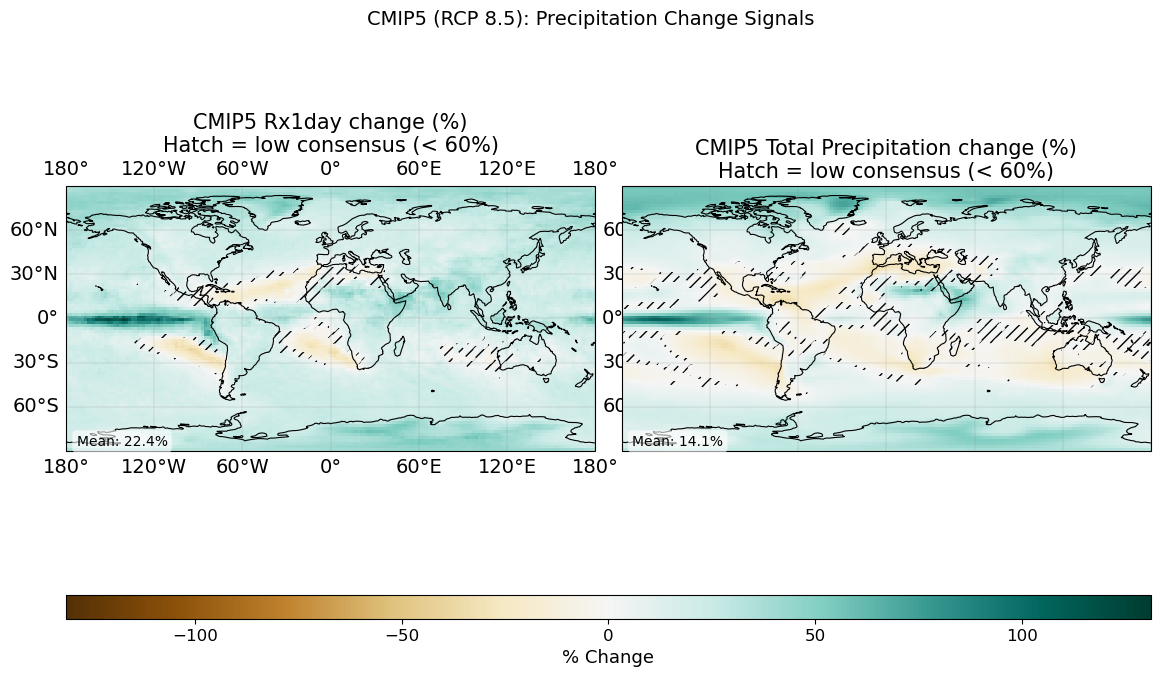

In [34]:
cmax = float(np.nanmax(np.abs([c5_rx.min(), c5_rx.max(), c5_total.min(), c5_total.max()])))
vmin, vmax = -cmax, cmax
fig = plt.figure(figsize=(14, 7))
gs2 = plt.GridSpec(2, 2, height_ratios=[20, 1], hspace=0.15, wspace=0.05)
for col, (data, con, title) in enumerate([
    (c5_rx,    c5_con_rx,    'CMIP5 Rx1day change (%)'),
    (c5_total, c5_con_total, 'CMIP5 Total Precipitation change (%)')]):
    ax = fig.add_subplot(gs2[0, col], projection=ccrs.PlateCarree())
    data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='BrBG', vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f'{title}\nHatch = low consensus (< {int(CONSENSUS_THRESHOLD*100)}%)')
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.gridlines(draw_labels=(col==0), linewidth=0.3, color='gray', alpha=0.5)
    ax.contourf(data.lon, data.lat, np.where(con<CONSENSUS_THRESHOLD, 1, np.nan),
                levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
    ax.text(0.02, 0.02, f'Mean: {float(data.mean()):.1f}%', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))
    last_ax = ax
fig.colorbar(last_ax.collections[0], cax=fig.add_subplot(gs2[1,:]),
             orientation='horizontal', label='% Change')
plt.suptitle('CMIP5 (RCP 8.5): Precipitation Change Signals', fontsize=14)
plt.tight_layout(); plt.show()


### 1.3 Classify CMIP5 Grid Cells


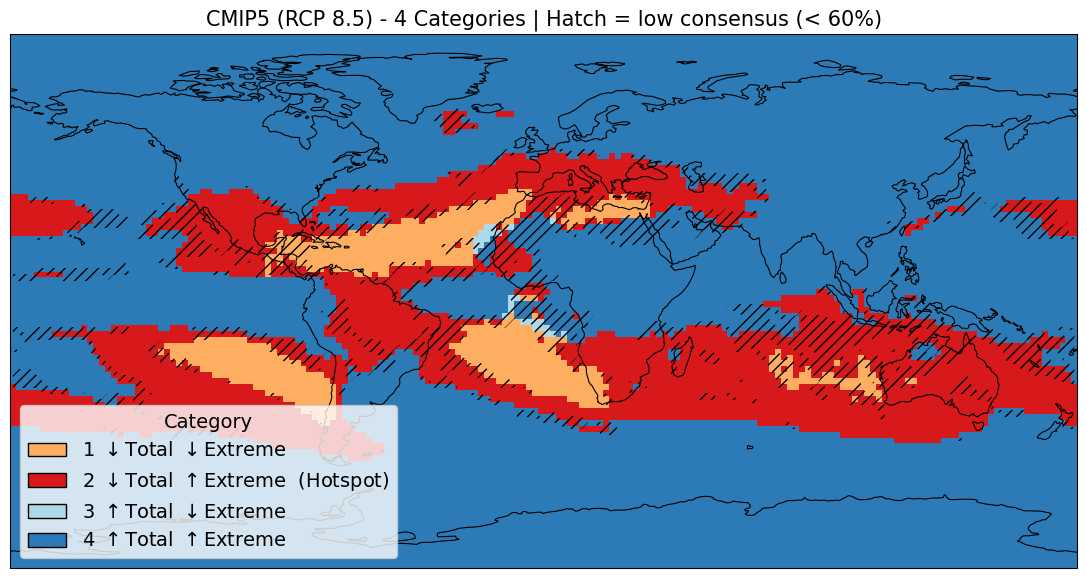

In [35]:
c5_class = classify_grid(c5_total, c5_rx)
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
c5_class.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=CAT_CMAP, norm=CAT_NORM, add_colorbar=False)
ax.contourf(c5_total.lon, c5_total.lat,
            np.where((c5_con_total<CONSENSUS_THRESHOLD)|(c5_con_rx<CONSENSUS_THRESHOLD), 1, np.nan),
            levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.legend(handles=[Patch(facecolor=CAT_COLORS[c], edgecolor='k', label=CAT_LABELS[c]) for c in [1,2,3,4]],
          loc='lower left', title='Category')
ax.set_title(f'CMIP5 (RCP 8.5) - 4 Categories | Hatch = low consensus (< {int(CONSENSUS_THRESHOLD*100)}%)')
plt.tight_layout(); plt.show()


### 1.4 CMIP5 Land Coverage Statistics


In [36]:
# Compute land mask on CMIP5 grid
c5_land_mask  = create_land_mask(c5_rx.lat.values, c5_rx.lon.values)
c5_class_land = c5_class.where(c5_land_mask == 1)
total_land_c5 = int(np.isfinite(c5_class_land).sum())
total_all_c5  = int(np.count_nonzero(~np.isnan(c5_class.values)))
c5_stats = pd.DataFrame([
    {'Category': c, 'Description': CAT_LABELS[c],
     'Global %': round(100*np.count_nonzero(c5_class.values==c)/total_all_c5, 2),
     'Land %':   round(100*int((c5_class_land==c).sum())/total_land_c5, 2)}
    for c in [1,2,3,4]])
display(c5_stats)


C:\Users\raznu\AppData\Local\Temp\ipykernel_23652\2757003760.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')).to_crs('EPSG:4326')


,Category,Description,Global %,Land %
0,1,1 $\downarrow$Total $\downarrow$Extreme,4.96,7.34
1,2,2 $\downarrow$Total $\uparrow$Extreme (Hotspot),20.46,20.03
2,3,3 $\uparrow$Total $\downarrow$Extreme,0.18,0.19
3,4,4 $\uparrow$Total $\uparrow$Extreme,74.40,72.44


### 1.5 Polygonize CMIP5 Categories


In [37]:
c5_cat_gdf = polygonize(c5_class, c5_total)
print(f'CMIP5 polygons: {len(c5_cat_gdf)}')


CMIP5 polygons: 54


### 1.6 Load Urban Data (GHS-BUILT-S) — shared with Section 2


In [38]:
rows, cols, percents = [], [], []
print(f'Reading urban raster (threshold={URBAN_THRESHOLD}%)...')
with rasterio.open(URBAN_RASTER_PATH) as src:
    height, width = src.height, src.width
    urb_tf = src.transform
    for i in range(0, height, RASTER_BLOCK_SIZE):
        for j in range(0, width, RASTER_BLOCK_SIZE):
            win = rasterio.windows.Window(j, i,
                    min(RASTER_BLOCK_SIZE, width-j), min(RASTER_BLOCK_SIZE, height-i))
            block = src.read(1, window=win, masked=True)
            pct   = 100 * block / 1_000_000
            mask  = (pct >= URBAN_THRESHOLD) & (~block.mask)
            r_idx, c_idx = np.where(mask)
            rows.extend(r_idx + i); cols.extend(c_idx + j); percents.extend(pct[mask].data)
xs, ys = rasterio.transform.xy(urb_tf, rows, cols)
transformer = Transformer.from_crs(MOLLWEIDE_CRS, 4326, always_xy=True)
lons, lats  = transformer.transform(xs, ys)
gdf_urban = gpd.GeoDataFrame(
    {'longitude': lons, 'latitude': lats, 'percent_built': percents},
    geometry=gpd.points_from_xy(lons, lats), crs='EPSG:4326')
print(f'Urban GeoDataFrame: {len(gdf_urban):,} points')


Reading urban raster (threshold=38%)...
Urban GeoDataFrame: 53,826 points


### 1.7 Join Urban Cells to CMIP5 Categories


In [39]:
c5_urban_join = join_urban(gdf_urban, c5_cat_gdf, c5_rx, c5_con_total, c5_con_rx)
print(f'Joined (CMIP5): {len(c5_urban_join):,} | Consensus: {int(c5_urban_join["consensus"].sum()):,}')


Joined (CMIP5): 53,826 | Consensus: 39,468


### 1.8 CMIP5 Urban Area by Category Table
> **PCT fix:** consensus % relative to consensus urban area only (corrected denominator).


In [40]:
c5_urban_df = build_urban_table(c5_urban_join, 'CMIP5')
display(c5_urban_df)


,Category,Description,% of Urban [CMIP5],% of Consensus Urban [CMIP5]
0,1,1 $\downarrow$Total $\downarrow$Extreme,4.32,3.91
1,2,2 $\downarrow$Total $\uparrow$Extreme (Hotspot),24.36,17.67
2,3,3 $\uparrow$Total $\downarrow$Extreme,0.00,0.00
3,4,4 $\uparrow$Total $\uparrow$Extreme,71.32,78.42


### 1.9 CMIP5 Publication Figure


Saved: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_1_CMIP5_ColorblindSafe.pdf


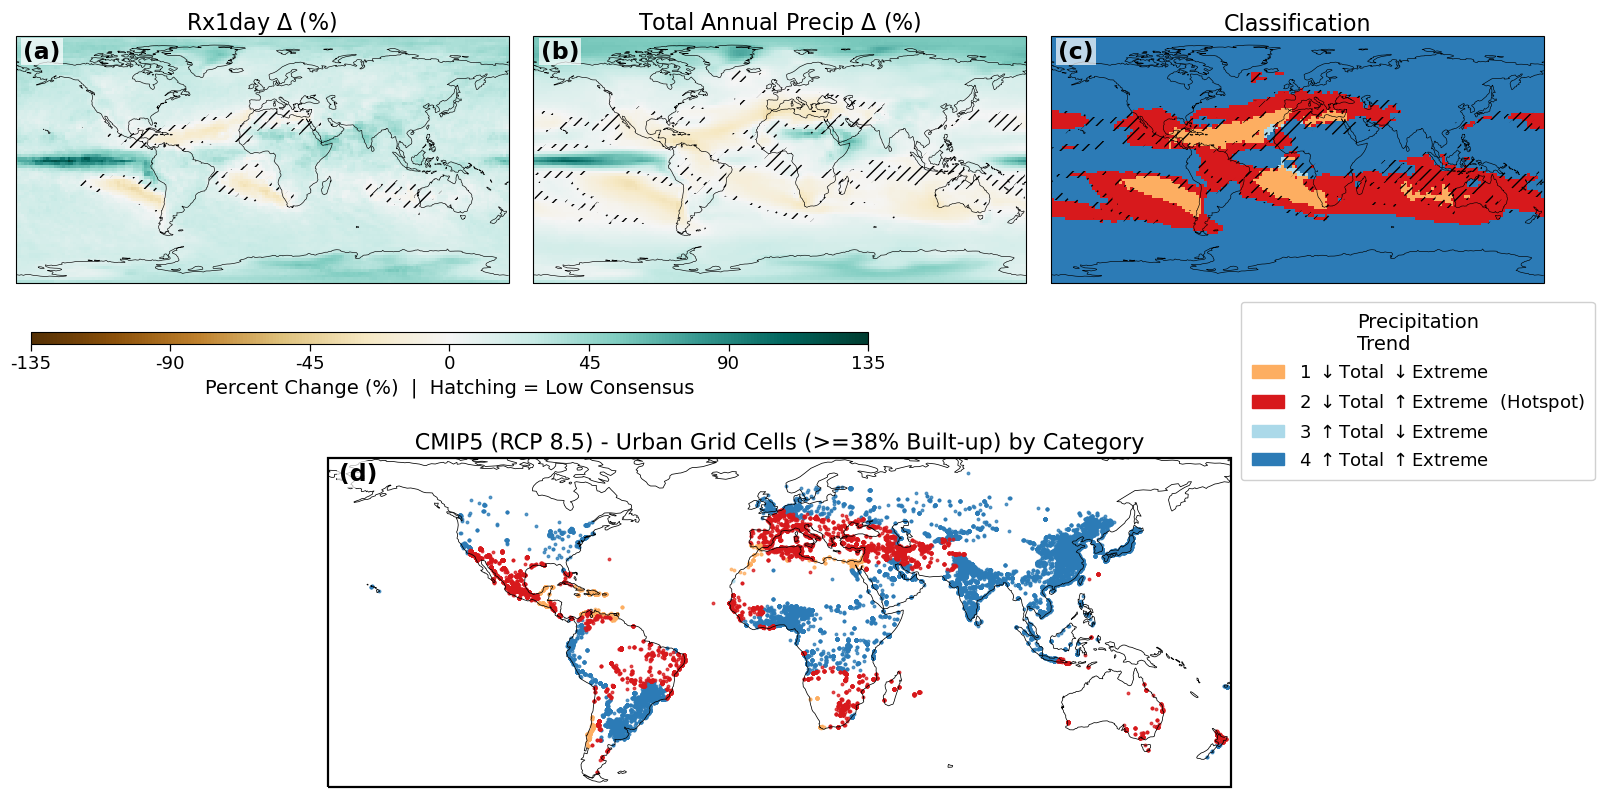

In [41]:
pub_figure(c5_rx, c5_total, c5_con_rx, c5_con_total, c5_class, c5_urban_join,
           scenario_label='CMIP5 (RCP 8.5)',
           out_filename='Fig_1_CMIP5_ColorblindSafe.pdf')


---
## Section 2: CMIP6 Analysis (SSP 8.5)


### 2.1 Load CMIP6 Data


In [42]:
c6_ds_rx      = xr.open_dataset(CMIP6_PATH_RX1DAY)
c6_ds_rx5     = xr.open_dataset(CMIP6_PATH_RX5DAY)
c6_ds_total   = xr.open_dataset(CMIP6_PATH_TOTAL)
c6_ds_con_rx  = xr.open_dataset(CMIP6_PATH_CON_RX1DAY)
c6_ds_con_rx5 = xr.open_dataset(CMIP6_PATH_CON_RX5DAY)
c6_ds_con_total = xr.open_dataset(CMIP6_PATH_CON_TOTAL)

c6_rx      = c6_ds_rx[get_var(c6_ds_rx)]
c6_rx5     = c6_ds_rx5[get_var(c6_ds_rx5)]
c6_total   = c6_ds_total[get_var(c6_ds_total)]
c6_con_rx  = c6_ds_con_rx[get_var(c6_ds_con_rx)]
c6_con_rx5 = c6_ds_con_rx5[get_var(c6_ds_con_rx5)]
c6_con_total = c6_ds_con_total[get_var(c6_ds_con_total)]
print(f'CMIP6 loaded: shape={c6_rx.shape}')


CMIP6 loaded: shape=(180, 360)


### 2.2 Visualize CMIP6 Precipitation Changes


C:\Users\raznu\AppData\Local\Temp\ipykernel_23652\3639602374.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


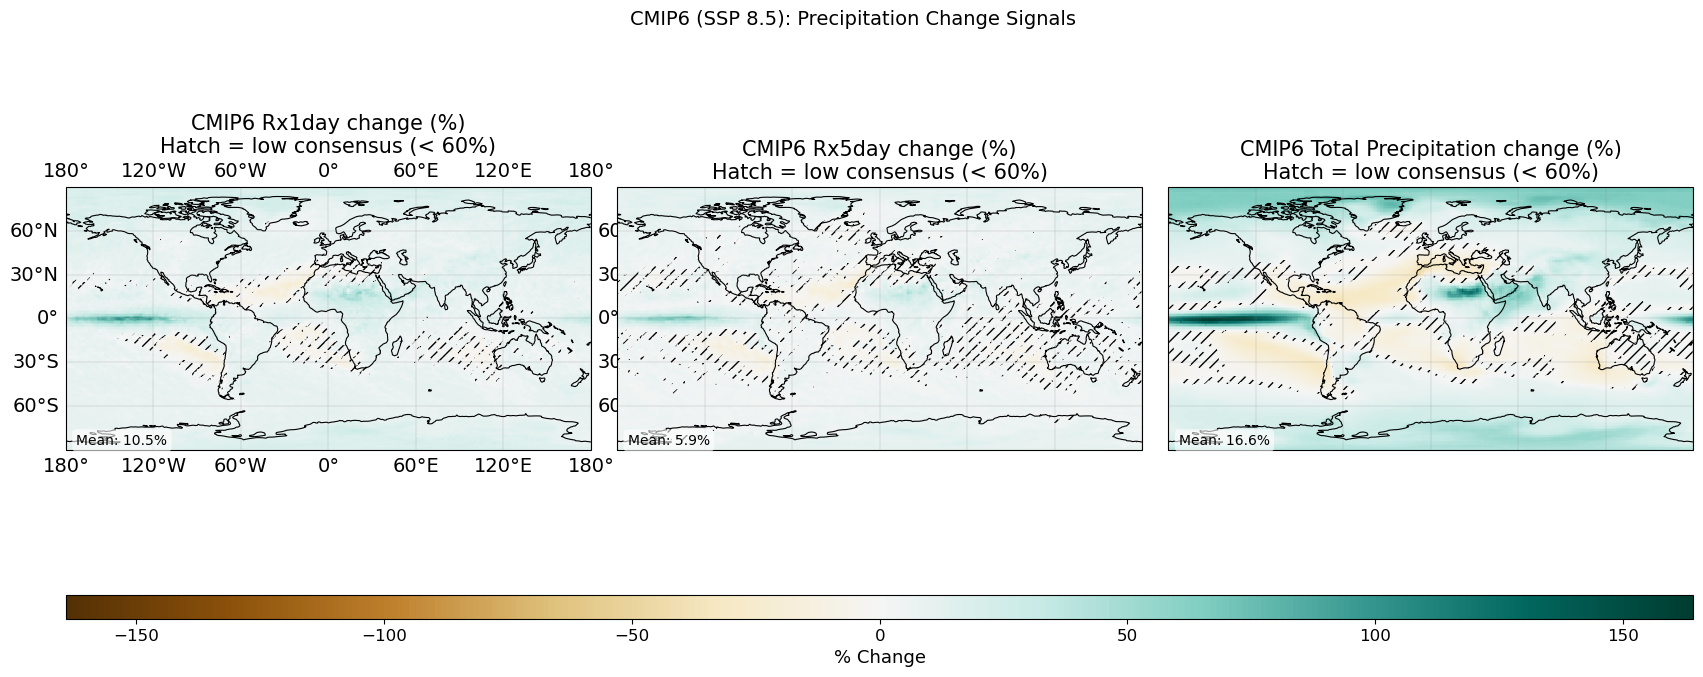

In [43]:
cmax = float(np.nanmax(np.abs([c6_rx.min(), c6_rx.max(), c6_rx5.min(), c6_rx5.max(),
                               c6_total.min(), c6_total.max()])))
vmin, vmax = -cmax, cmax
fig = plt.figure(figsize=(21, 7))
gs3 = plt.GridSpec(2, 3, height_ratios=[20, 1], hspace=0.15, wspace=0.05)
for col, (data, con, title) in enumerate([
    (c6_rx,    c6_con_rx,    'CMIP6 Rx1day change (%)'),
    (c6_rx5,   c6_con_rx5,   'CMIP6 Rx5day change (%)'),
    (c6_total, c6_con_total, 'CMIP6 Total Precipitation change (%)')]):
    ax = fig.add_subplot(gs3[0, col], projection=ccrs.PlateCarree())
    data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='BrBG', vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_title(f'{title}\nHatch = low consensus (< {int(CONSENSUS_THRESHOLD*100)}%)')
    ax.coastlines(resolution='110m', linewidth=0.8)
    ax.gridlines(draw_labels=(col==0), linewidth=0.3, color='gray', alpha=0.5)
    ax.contourf(data.lon, data.lat, np.where(con<CONSENSUS_THRESHOLD, 1, np.nan),
                levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
    ax.text(0.02, 0.02, f'Mean: {float(data.mean()):.1f}%', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='none'))
    last_ax = ax
fig.colorbar(last_ax.collections[0], cax=fig.add_subplot(gs3[1,:]),
             orientation='horizontal', label='% Change')
plt.suptitle('CMIP6 (SSP 8.5): Precipitation Change Signals', fontsize=14)
plt.tight_layout(); plt.show()


### 2.3 Classify CMIP6 Grid Cells


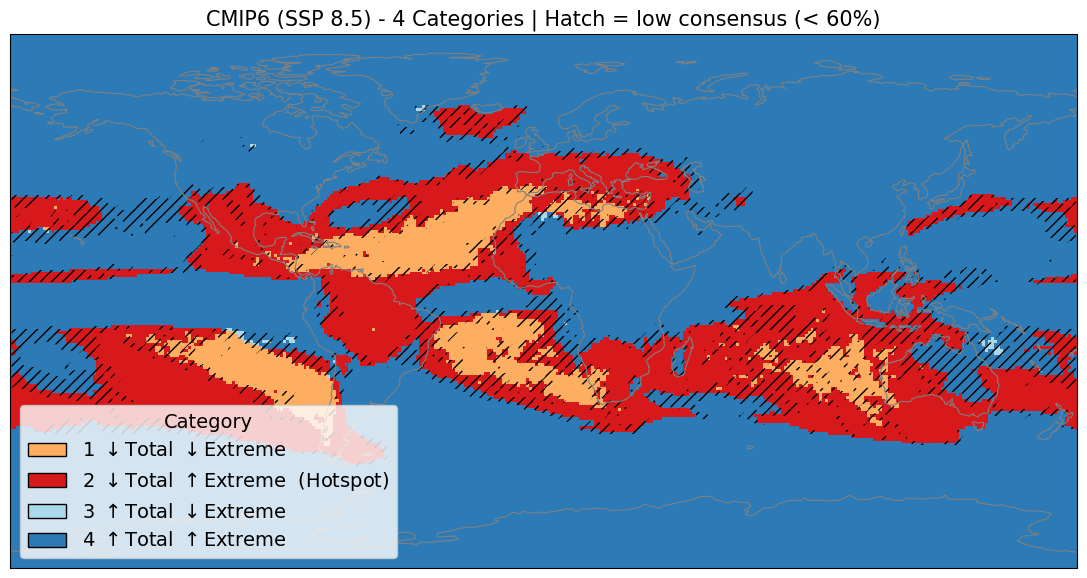

In [44]:
c6_class = classify_grid(c6_total, c6_rx)
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
c6_class.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=CAT_CMAP, norm=CAT_NORM, add_colorbar=False)
ax.contourf(c6_total.lon, c6_total.lat,
            np.where((c6_con_total<CONSENSUS_THRESHOLD)|(c6_con_rx<CONSENSUS_THRESHOLD), 1, np.nan),
            levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
ax.legend(handles=[Patch(facecolor=CAT_COLORS[c], edgecolor='k', label=CAT_LABELS[c]) for c in [1,2,3,4]],
          loc='lower left', title='Category')
ax.set_title(f'CMIP6 (SSP 8.5) - 4 Categories | Hatch = low consensus (< {int(CONSENSUS_THRESHOLD*100)}%)')
plt.tight_layout(); plt.show()


### 2.4 CMIP6 Land Coverage Statistics


In [45]:
# Separate land mask computed on CMIP6 grid to avoid dimension mismatch with CMIP5
c6_land_mask  = create_land_mask(c6_rx.lat.values, c6_rx.lon.values)
c6_class_land = c6_class.where(c6_land_mask == 1)
total_land_c6 = int(np.isfinite(c6_class_land).sum())
total_all_c6  = int(np.count_nonzero(~np.isnan(c6_class.values)))
c6_stats = pd.DataFrame([
    {'Category': c, 'Description': CAT_LABELS[c],
     'Global %': round(100*np.count_nonzero(c6_class.values==c)/total_all_c6, 2),
     'Land %':   round(100*int((c6_class_land==c).sum())/total_land_c6, 2)}
    for c in [1,2,3,4]])
display(c6_stats)


C:\Users\raznu\AppData\Local\Temp\ipykernel_23652\2757003760.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')).to_crs('EPSG:4326')


,Category,Description,Global %,Land %
0,1,1 $\downarrow$Total $\downarrow$Extreme,5.46,8.07
1,2,2 $\downarrow$Total $\uparrow$Extreme (Hotspot),19.63,18.40
2,3,3 $\uparrow$Total $\downarrow$Extreme,0.10,0.03
3,4,4 $\uparrow$Total $\uparrow$Extreme,74.81,73.50


### 2.5 Polygonize CMIP6 Categories


In [46]:
c6_cat_gdf = polygonize(c6_class, c6_total)
print(f'CMIP6 polygons: {len(c6_cat_gdf)}')


CMIP6 polygons: 140


### 2.6 Join Urban Cells to CMIP6 Categories


In [47]:
# Reuse gdf_urban loaded in Section 1.6
c6_urban_join = join_urban(gdf_urban, c6_cat_gdf, c6_rx, c6_con_total, c6_con_rx)
print(f'Joined (CMIP6): {len(c6_urban_join):,} | Consensus: {int(c6_urban_join["consensus"].sum()):,}')


Joined (CMIP6): 53,826 | Consensus: 44,119


### 2.7 CMIP6 Urban Area by Category Table
> **PCT fix:** consensus % relative to consensus urban area only.


In [48]:
c6_urban_df = build_urban_table(c6_urban_join, 'CMIP6')
display(c6_urban_df)


,Category,Description,% of Urban [CMIP6],% of Consensus Urban [CMIP6]
0,1,1 $\downarrow$Total $\downarrow$Extreme,2.98,1.16
1,2,2 $\downarrow$Total $\uparrow$Extreme (Hotspot),26.04,19.29
2,3,3 $\uparrow$Total $\downarrow$Extreme,0.01,0.00
3,4,4 $\uparrow$Total $\uparrow$Extreme,70.97,79.56


### 2.8 CMIP6 Publication Figure


Saved: D:\Development\RESEARCH\Documents\Papers\urban_runoff_response_to_hpes\Nature\Figures\Fig_1_CMIP6_ColorblindSafe.pdf


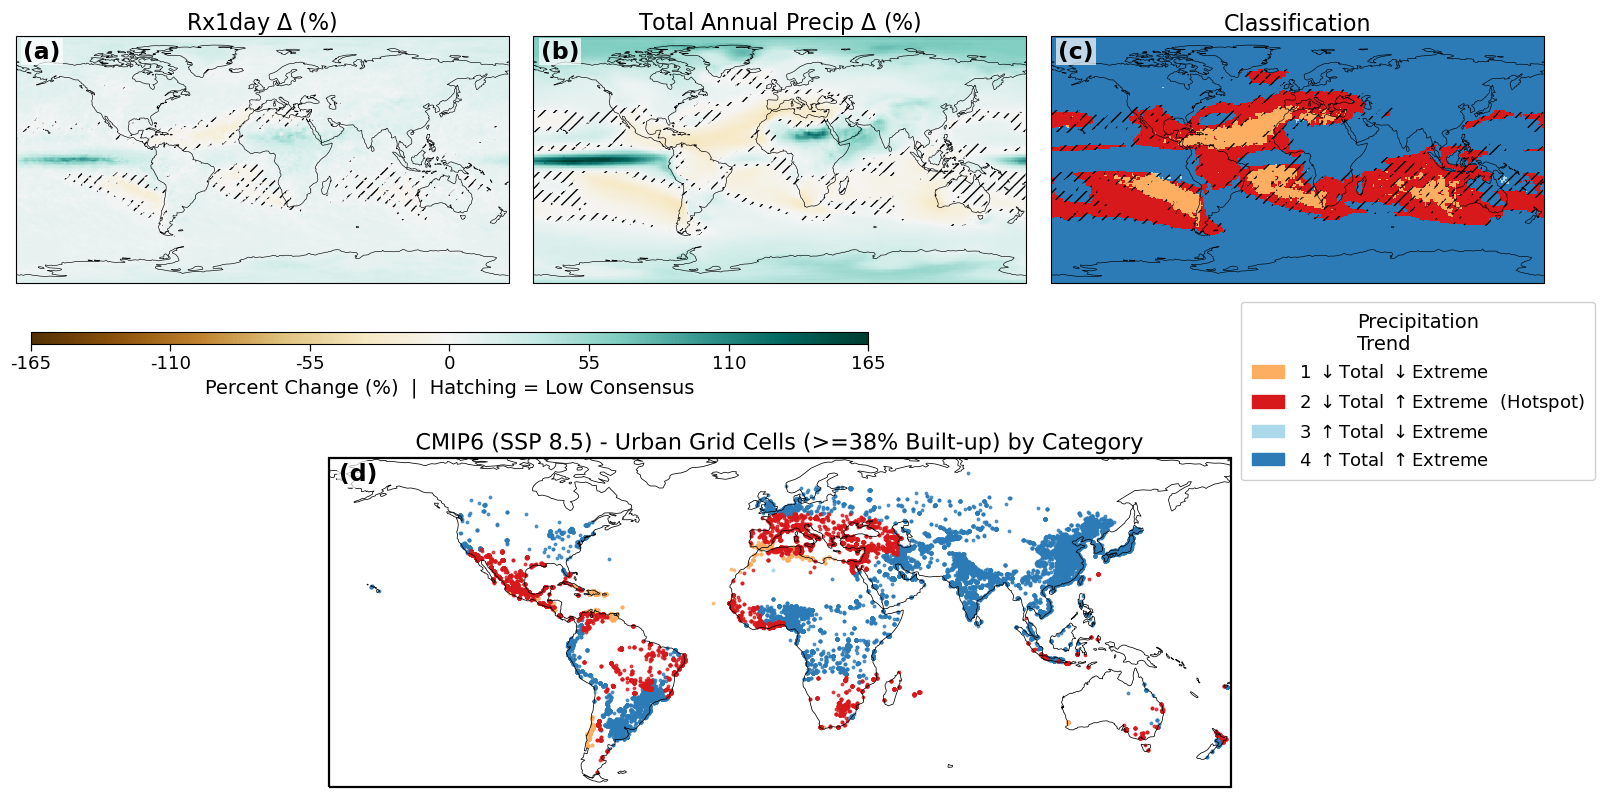

In [49]:
pub_figure(c6_rx, c6_total, c6_con_rx, c6_con_total, c6_class, c6_urban_join,
           scenario_label='CMIP6 (SSP 8.5)',
           out_filename='Fig_1_CMIP6_ColorblindSafe.pdf')


---
## Section 3: CMIP5 vs CMIP6 Comparison


### 3.1 Side-by-Side Classification Maps
**RED (Category 2) = Decrease in total precipitation + Increase in extreme precipitation.**


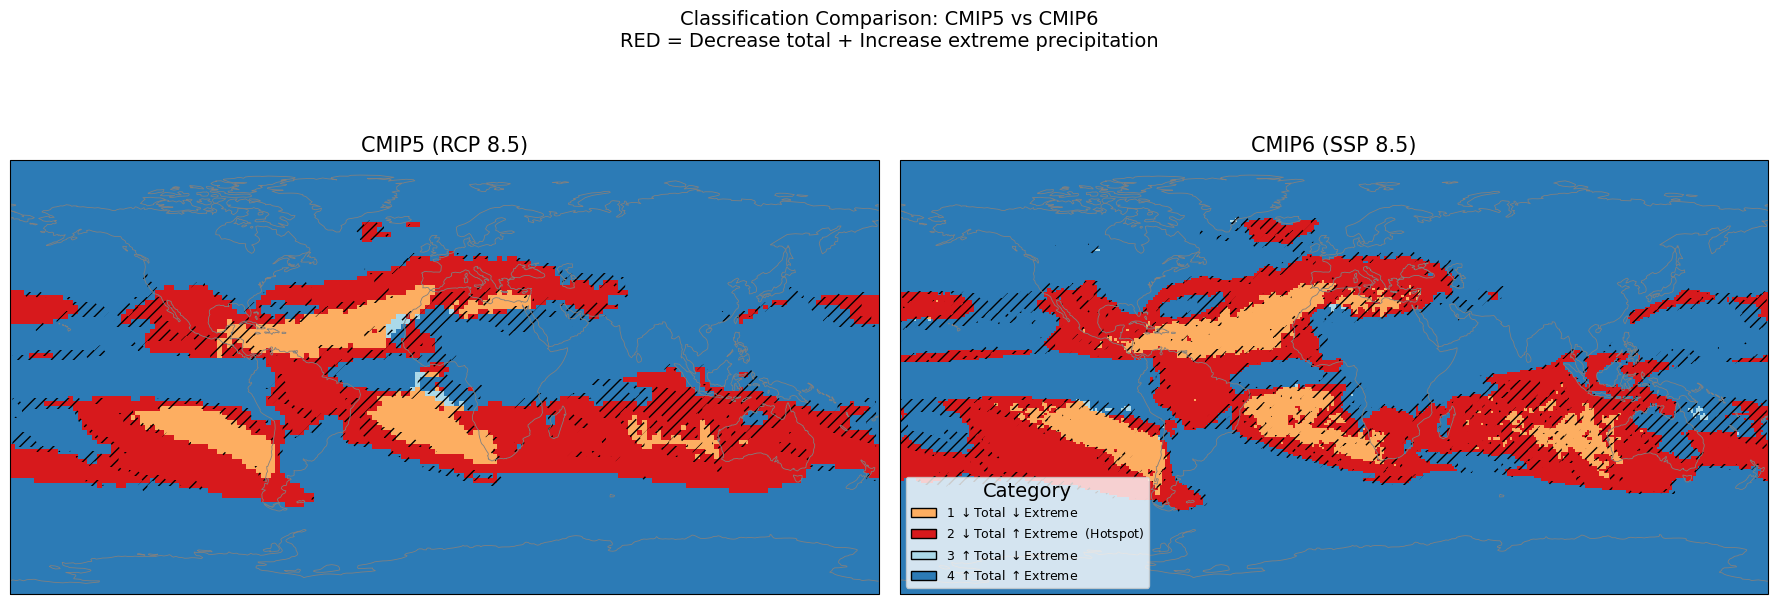

In [50]:
fig = plt.figure(figsize=(18, 7))
for col, (cls, con_rx_, con_total_, title) in enumerate([
    (c5_class, c5_con_rx, c5_con_total, 'CMIP5 (RCP 8.5)'),
    (c6_class, c6_con_rx, c6_con_total, 'CMIP6 (SSP 8.5)'),
]):
    ax = fig.add_subplot(1, 2, col+1, projection=ccrs.PlateCarree())
    cls.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=CAT_CMAP, norm=CAT_NORM, add_colorbar=False)
    ax.contourf(con_total_.lon, con_total_.lat,
                np.where((con_total_<CONSENSUS_THRESHOLD)|(con_rx_<CONSENSUS_THRESHOLD), 1, np.nan),
                levels=1, hatches=['///'], colors='none', transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='gray')
    ax.set_title(title, fontsize=15)
    if col == 1:
        ax.legend(handles=[Patch(facecolor=CAT_COLORS[c], edgecolor='k', label=CAT_LABELS[c]) for c in [1,2,3,4]],
                  loc='lower left', title='Category', fontsize=9)
plt.suptitle('Classification Comparison: CMIP5 vs CMIP6\n'
             'RED = Decrease total + Increase extreme precipitation', fontsize=14)
plt.tight_layout(); plt.show()


### 3.2 Side-by-Side Urban Maps
**RED = Category 2 (Hotspot).**


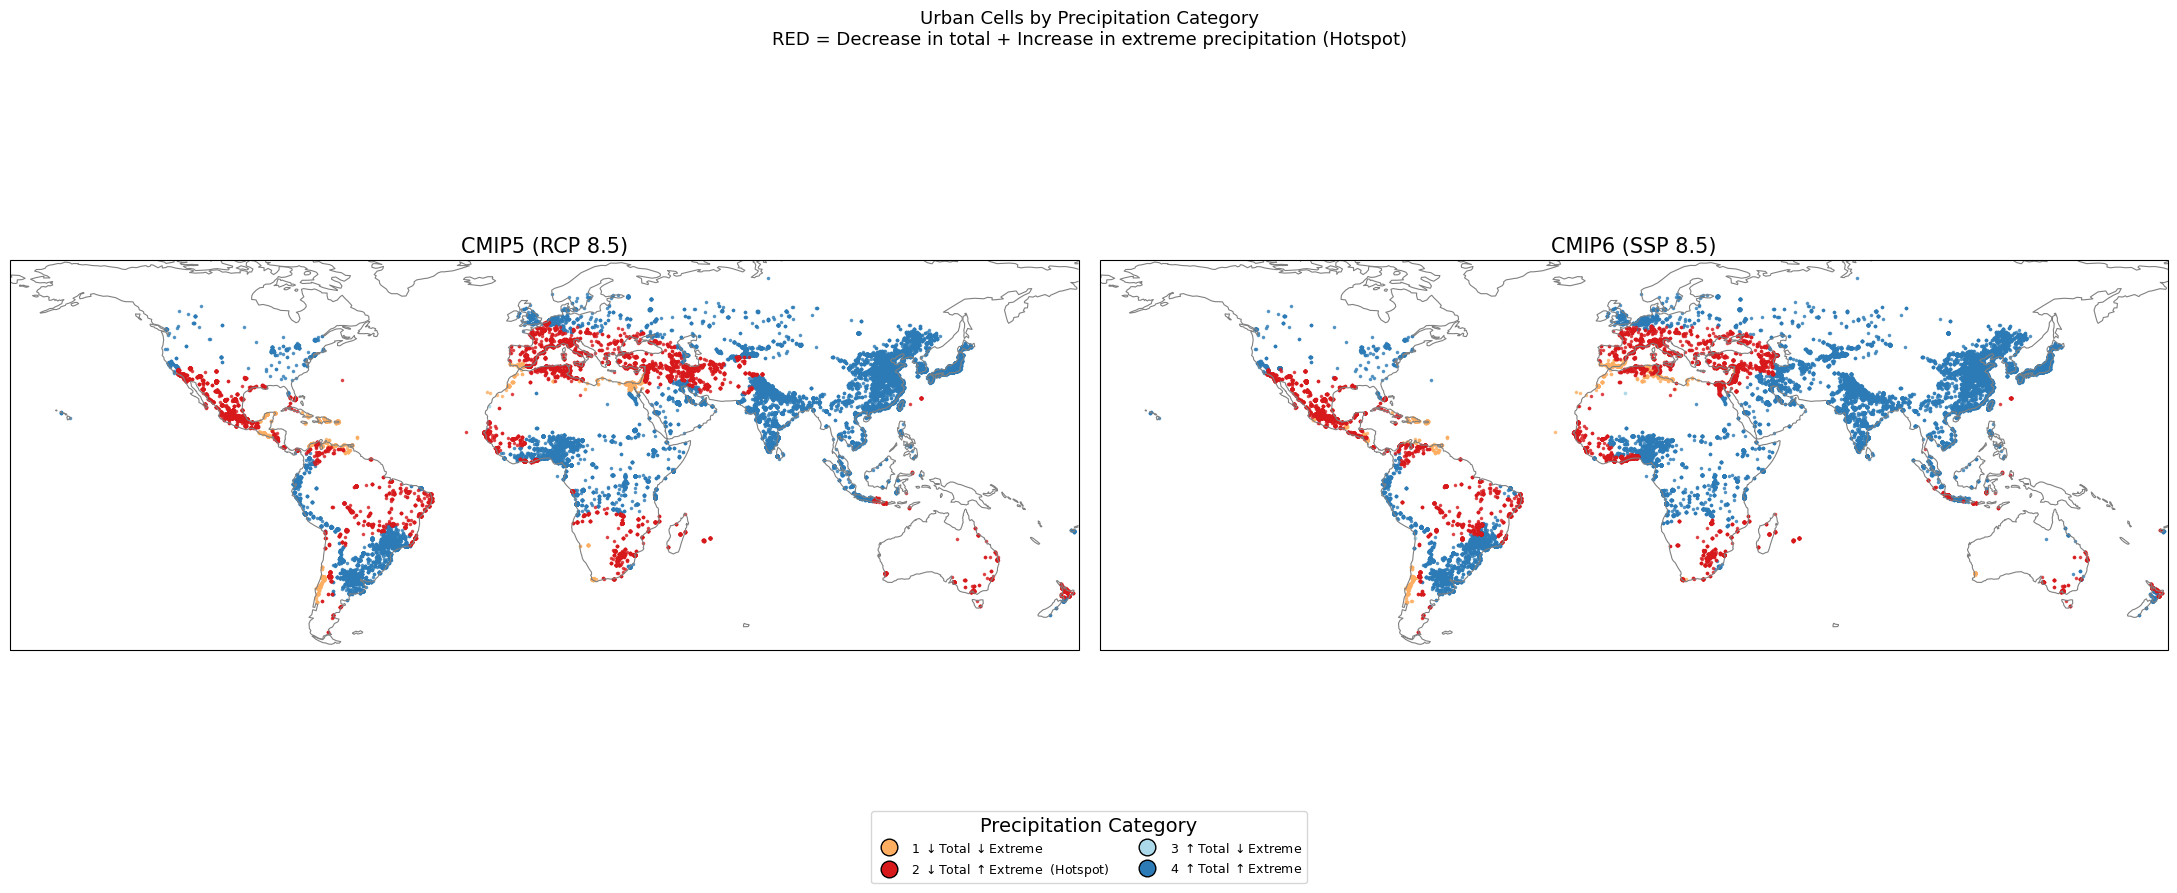

In [51]:
fig = plt.figure(figsize=(22, 8))
for col, (uj, title) in enumerate([
    (c5_urban_join, 'CMIP5 (RCP 8.5)'),
    (c6_urban_join, 'CMIP6 (SSP 8.5)'),
]):
    ax = fig.add_subplot(1, 2, col+1, projection=ccrs.PlateCarree())
    valid = uj[uj['category'].notna()]
    for cat in [1, 3, 4, 2]:
        sub = valid[valid['category'] == cat]
        if not sub.empty:
            gpd.GeoDataFrame(sub, geometry='geometry', crs='EPSG:4326').plot(
                ax=ax, color=CAT_COLORS[cat], markersize=2.5, alpha=0.7, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray')
    ax.set_title(title, fontsize=15)
fig.legend(
    handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor=CAT_COLORS[c],
             markersize=12, markeredgecolor='black', lw=0, label=CAT_LABELS[c]) for c in [1,2,3,4]],
    title='Precipitation Category', loc='lower center', ncol=2, fontsize=9,
    bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Urban Cells by Precipitation Category\n'
             'RED = Decrease in total + Increase in extreme precipitation (Hotspot)',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


### 3.3 Percentage Comparison Table


In [52]:
comp_df = c5_urban_df.merge(c6_urban_df, on=['Category', 'Description'])
comp_df['Delta % Urban (C6-C5)']     = (comp_df['% of Urban [CMIP6]']           - comp_df['% of Urban [CMIP5]']).round(2)
comp_df['Delta % Consensus (C6-C5)'] = (comp_df['% of Consensus Urban [CMIP6]'] - comp_df['% of Consensus Urban [CMIP5]']).round(2)
display(comp_df)


,Category,Description,% of Urban [CMIP5],% of Consensus Urban [CMIP5],% of Urban [CMIP6],% of Consensus Urban [CMIP6],Delta % Urban (C6-C5),Delta % Consensus (C6-C5)
0,1,1 $\downarrow$Total $\downarrow$Extreme,4.32,3.91,2.98,1.16,-1.34,-2.75
1,2,2 $\downarrow$Total $\uparrow$Extreme (Hotspot),24.36,17.67,26.04,19.29,1.68,1.62
2,3,3 $\uparrow$Total $\downarrow$Extreme,0.00,0.00,0.01,0.00,0.01,0.00
3,4,4 $\uparrow$Total $\uparrow$Extreme,71.32,78.42,70.97,79.56,-0.35,1.14


### 3.4 Bar Chart — Urban Area Percentage by Category


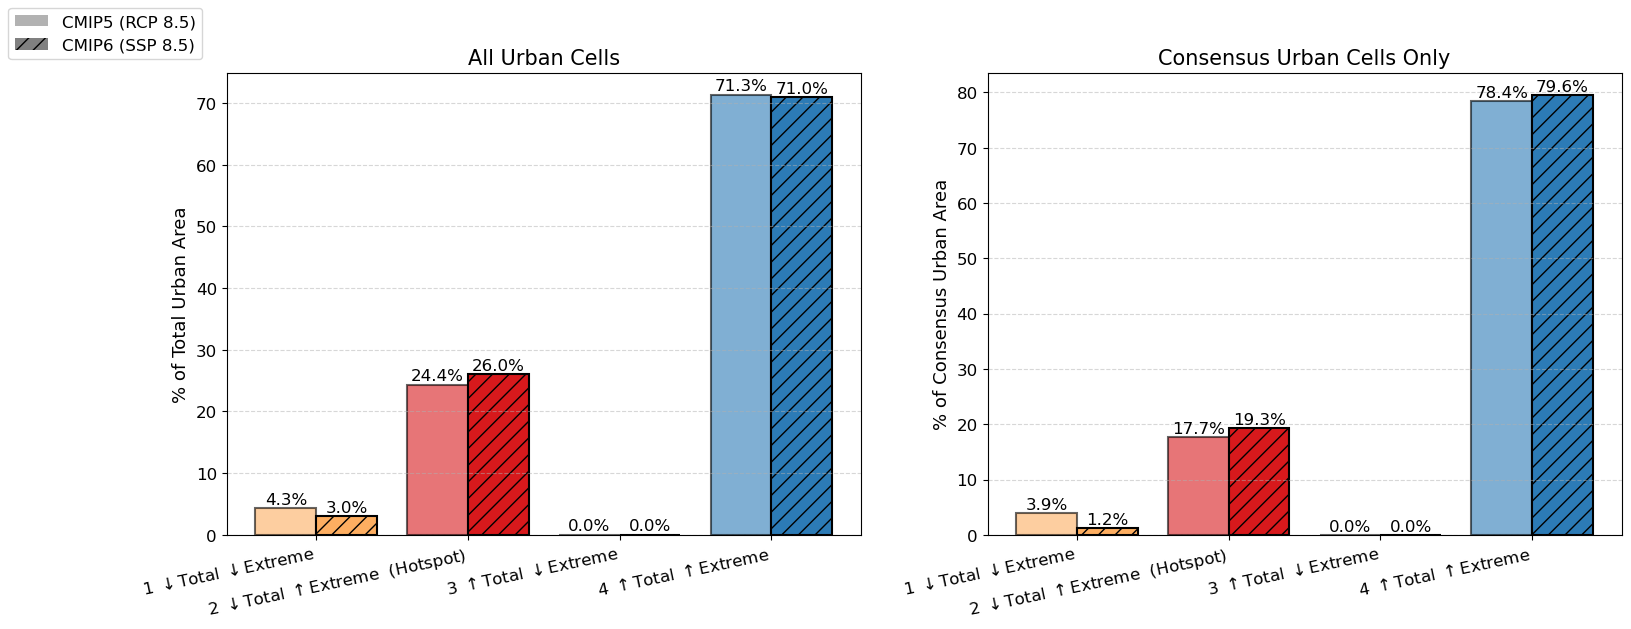

In [69]:
cats  = comp_df['Category'].astype(int).tolist()
x     = np.arange(len(cats))
w     = 0.2
xlbls = [CAT_LABELS[c] for c in cats]
edges = ['black' if c == 2 else 'none' for c in cats]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, c5v, c6v, ylabel, subtitle in [
    (axes[0],
     comp_df['% of Urban [CMIP5]'].tolist(),
     comp_df['% of Urban [CMIP6]'].tolist(),
     '% of Total Urban Area', 'All Urban Cells'),
    (axes[1],
     comp_df['% of Consensus Urban [CMIP5]'].tolist(),
     comp_df['% of Consensus Urban [CMIP6]'].tolist(),
     '% of Consensus Urban Area', 'Consensus Urban Cells Only')]:
    b5 = ax.bar(x-w, c5v, w*2, color=[CAT_COLORS[c] for c in cats], alpha=0.6,
                edgecolor=edges, linewidth=1.5, label='CMIP5')
    b6 = ax.bar(x+w, c6v, w*2, color=[CAT_COLORS[c] for c in cats], alpha=1.0,
                edgecolor=edges, linewidth=1.5, hatch='//', label='CMIP6')
    for bar, val in list(zip(b5, c5v)) + list(zip(b6, c6v)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(xlbls, rotation=12, ha='right', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_title(subtitle)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
from matplotlib.patches import Patch as _P
fig.legend(
    handles=[_P(facecolor='gray', alpha=0.6, label='CMIP5 (RCP 8.5)'),
             _P(facecolor='gray', alpha=1.0, hatch='//', label='CMIP6 (SSP 8.5)')],
    loc='upper left', fontsize=12)
# plt.suptitle('CMIP5 vs CMIP6: Urban Area by Precipitation Category\n'
#              '(Red bars = Hotspot: decrease total + increase extreme)', fontsize=13)
# plt.tight_layout();
plt.show()


---
## Section 4: Sensitivity Analysis — CMIP5 vs CMIP6

Tests robustness of the **Category 2 (hotspot)** urban fraction to:
- Varying **consensus threshold** (how strict we are about model agreement)
- Varying **urban mask threshold** (how we define an urban cell)

Each plot shows one line for CMIP5 (RCP 8.5) and one for CMIP6 (SSP 8.5).


### 4.1 Consensus Threshold Sensitivity


In [54]:
def _consensus_sens(urban_join, data_rx, con_total, con_rx, thresholds):
    """
    For each threshold T, computes two metrics:
      - pct_all_urban:       Cat2 cells passing T  /  all valid urban cells
      - pct_consensus_urban: Cat2 cells passing T  /  ALL cells passing T
    The second metric mirrors the PCT fix in build_urban_table.
    """
    valid_all  = urban_join[urban_join['category'].notna()].copy()
    total_urban = len(valid_all)
    lats, lons = data_rx.lat.values, data_rx.lon.values
    li = np.abs(valid_all['latitude'].values[:,None]  - lats[None,:]).argmin(axis=1)
    lj = np.abs(valid_all['longitude'].values[:,None] - lons[None,:]).argmin(axis=1)
    is_cat2   = (valid_all['category'] == 2).values
    con_rx_v  = con_rx.values[li, lj]
    con_tot_v = con_total.values[li, lj]
    rows = []
    for t in thresholds:
        flag       = (con_rx_v >= t) & (con_tot_v >= t)
        total_cons = int(flag.sum())
        cat2_cons  = int((flag & is_cat2).sum())
        rows.append({
            'Consensus Threshold (%)': int(t * 100),
            'Consensus Urban Cells': total_cons,
            'Cat2 Count':            cat2_cons,
            'Cat2 % of All Urban':        round(100 * cat2_cons / total_urban,  2),
            'Cat2 % of Consensus Urban':  round(100 * cat2_cons / total_cons,   2)
                                          if total_cons > 0 else float('nan'),
        })
    return pd.DataFrame(rows)

print('Running consensus sensitivity ...')
df_con_c5 = _consensus_sens(c5_urban_join, c5_rx, c5_con_total, c5_con_rx,
                             CONSENSUS_THRESHOLDS_SENSITIVITY)
df_con_c6 = _consensus_sens(c6_urban_join, c6_rx, c6_con_total, c6_con_rx,
                             CONSENSUS_THRESHOLDS_SENSITIVITY)

print('CMIP5:'); display(df_con_c5)
print('CMIP6:'); display(df_con_c6)


Running consensus sensitivity ...
CMIP5:


,Consensus Threshold (%),Consensus Urban Cells,Cat2 Count,Cat2 % of All Urban,Cat2 % of Consensus Urban
0,50,49536,11552,21.46,23.32
1,55,46868,10995,20.43,23.46
2,60,39468,6973,12.95,17.67
3,65,33290,5851,10.87,17.58
4,70,23953,2302,4.28,9.61


CMIP6:


,Consensus Threshold (%),Consensus Urban Cells,Cat2 Count,Cat2 % of All Urban,Cat2 % of Consensus Urban
0,50,50936,12143,22.56,23.84
1,55,47241,10329,19.19,21.86
2,60,44119,8510,15.81,19.29
3,65,36584,4871,9.05,13.31
4,70,26375,2741,5.09,10.39


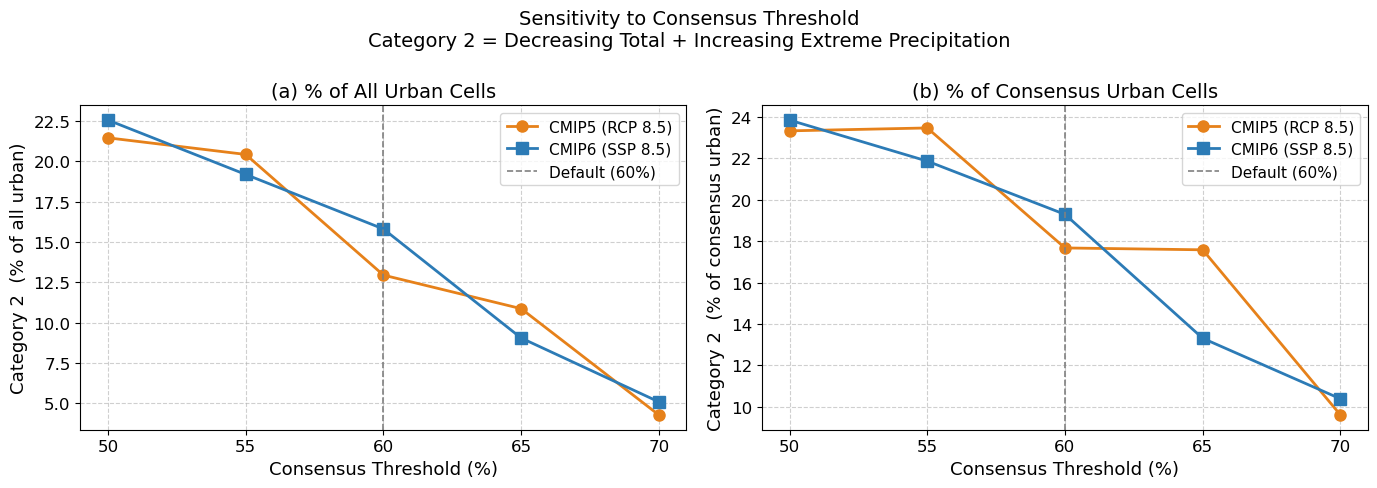

In [55]:
x_ticks = [int(t*100) for t in CONSENSUS_THRESHOLDS_SENSITIVITY]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, col_c5, col_c6, ylabel, title in [
    (axes[0],
     'Cat2 % of All Urban', 'Cat2 % of All Urban',
     'Category 2  (% of all urban)',
     '(a) % of All Urban Cells'),
    (axes[1],
     'Cat2 % of Consensus Urban', 'Cat2 % of Consensus Urban',
     'Category 2  (% of consensus urban)',
     '(b) % of Consensus Urban Cells'),
]:
    ax.plot(df_con_c5['Consensus Threshold (%)'], df_con_c5[col_c5],
            marker='o', linewidth=2, markersize=8, color='#e6811a', label='CMIP5 (RCP 8.5)')
    ax.plot(df_con_c6['Consensus Threshold (%)'], df_con_c6[col_c6],
            marker='s', linewidth=2, markersize=8, color='#2c7bb6', label='CMIP6 (SSP 8.5)')
    ax.axvline(x=60, color='gray', linestyle='--', linewidth=1.2, label='Default (60%)')
    ax.set_xticks(x_ticks)
    ax.set_xlabel('Consensus Threshold (%)', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Sensitivity to Consensus Threshold\n'
             'Category 2 = Decreasing Total + Increasing Extreme Precipitation', fontsize=14)
plt.tight_layout()
plt.show()


### 4.2 Urban Mask Threshold Sensitivity


In [56]:
def _urban_thresh_sens(cat_gdf_c5, cat_gdf_c6,
                        data_rx_c5, con_total_c5, con_rx_c5,
                        data_rx_c6, con_total_c6, con_rx_c6,
                        thresholds, urb_path, block_size, mollweide_crs):
    from pyproj import Transformer as _T
    transformer = _T.from_crs(mollweide_crs, 4326, always_xy=True)
    rows_c5, rows_c6 = [], []
    for thresh in thresholds:
        print(f'  Urban threshold: {thresh}%')
        rs, cs, ps = [], [], []
        with rasterio.open(urb_path) as src:
            h, w = src.height, src.width
            tf   = src.transform
            for i in range(0, h, block_size):
                for j in range(0, w, block_size):
                    win = rasterio.windows.Window(j, i,
                              min(block_size, w-j), min(block_size, h-i))
                    blk = src.read(1, window=win, masked=True)
                    pct = 100 * blk / 1_000_000
                    msk = (pct >= thresh) & (~blk.mask)
                    ri, ci = np.where(msk)
                    rs.extend(ri+i); cs.extend(ci+j); ps.extend(pct[msk].data)
        xs, ys = rasterio.transform.xy(tf, rs, cs)
        lons_t, lats_t = transformer.transform(xs, ys)
        gdf_t = gpd.GeoDataFrame(
            {'longitude': lons_t, 'latitude': lats_t, 'percent_built': ps},
            geometry=gpd.points_from_xy(lons_t, lats_t), crs='EPSG:4326')

        for cat_gdf, result_list in [(cat_gdf_c5, rows_c5), (cat_gdf_c6, rows_c6)]:
            joined = gpd.sjoin(gdf_t, cat_gdf, how='left', predicate='within')
            valid  = joined[joined['category'].notna()]
            total  = len(valid)
            count  = int((valid['category'] == 2).sum())
            pct_v  = round(100 * count / total, 2) if total > 0 else float('nan')
            result_list.append({'Urban Threshold (%)': int(thresh),
                                'Cat2 Count': count, 'Cat2 % of Urban': pct_v})
    return pd.DataFrame(rows_c5), pd.DataFrame(rows_c6)

print('Running urban-threshold sensitivity (reads raster multiple times — takes a few minutes)...')
df_urb_c5, df_urb_c6 = _urban_thresh_sens(
    c5_cat_gdf, c6_cat_gdf,
    c5_rx, c5_con_total, c5_con_rx,
    c6_rx, c6_con_total, c6_con_rx,
    URBAN_THRESHOLDS_SENSITIVITY,
    URBAN_RASTER_PATH, RASTER_BLOCK_SIZE, MOLLWEIDE_CRS)

print('CMIP5:'); display(df_urb_c5)
print('CMIP6:'); display(df_urb_c6)


Running urban-threshold sensitivity (reads raster multiple times — takes a few minutes)...
  Urban threshold: 10%
  Urban threshold: 20%
  Urban threshold: 30%
  Urban threshold: 38%
  Urban threshold: 50%
  Urban threshold: 60%
  Urban threshold: 70%
  Urban threshold: 80%
  Urban threshold: 90%
CMIP5:


,Urban Threshold (%),Cat2 Count,Cat2 % of Urban
0,10,284162,25.49
1,20,120816,27.12
2,30,45697,27.36
3,38,13113,24.36
4,50,846,26.17
5,60,185,32.40
6,70,55,57.29
7,80,19,86.36
8,90,5,83.33


CMIP6:


,Urban Threshold (%),Cat2 Count,Cat2 % of Urban
0,10,277014,24.85
1,20,119623,26.85
2,30,46556,27.87
3,38,14016,26.04
4,50,818,25.30
5,60,138,24.17
6,70,9,9.38
7,80,0,0.00
8,90,0,0.00


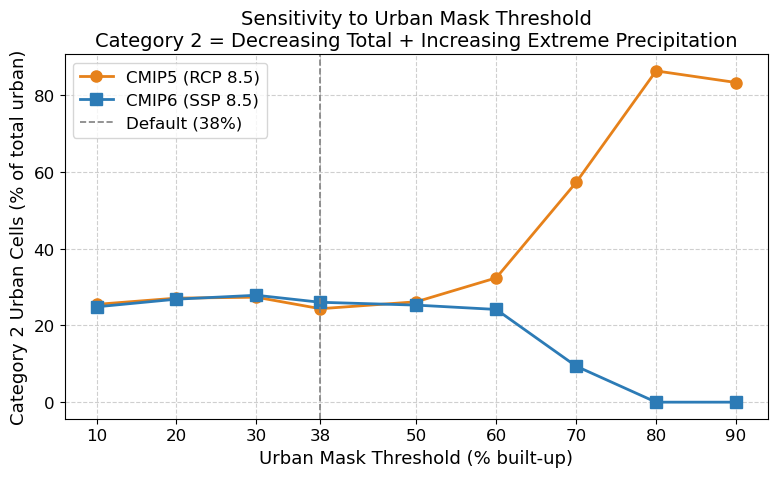

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_urb_c5['Urban Threshold (%)'], df_urb_c5['Cat2 % of Urban'],
        marker='o', linewidth=2, markersize=8, color='#e6811a', label='CMIP5 (RCP 8.5)')
ax.plot(df_urb_c6['Urban Threshold (%)'], df_urb_c6['Cat2 % of Urban'],
        marker='s', linewidth=2, markersize=8, color='#2c7bb6', label='CMIP6 (SSP 8.5)')
ax.axvline(x=URBAN_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Default ({URBAN_THRESHOLD}%)')
ax.set_xticks(URBAN_THRESHOLDS_SENSITIVITY)
ax.set_xlabel('Urban Mask Threshold (% built-up)', fontsize=13)
ax.set_ylabel('Category 2 Urban Cells (% of total urban)', fontsize=13)
ax.set_title('Sensitivity to Urban Mask Threshold\n'
             'Category 2 = Decreasing Total + Increasing Extreme Precipitation', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### 4.3 Combined Sensitivity Summary


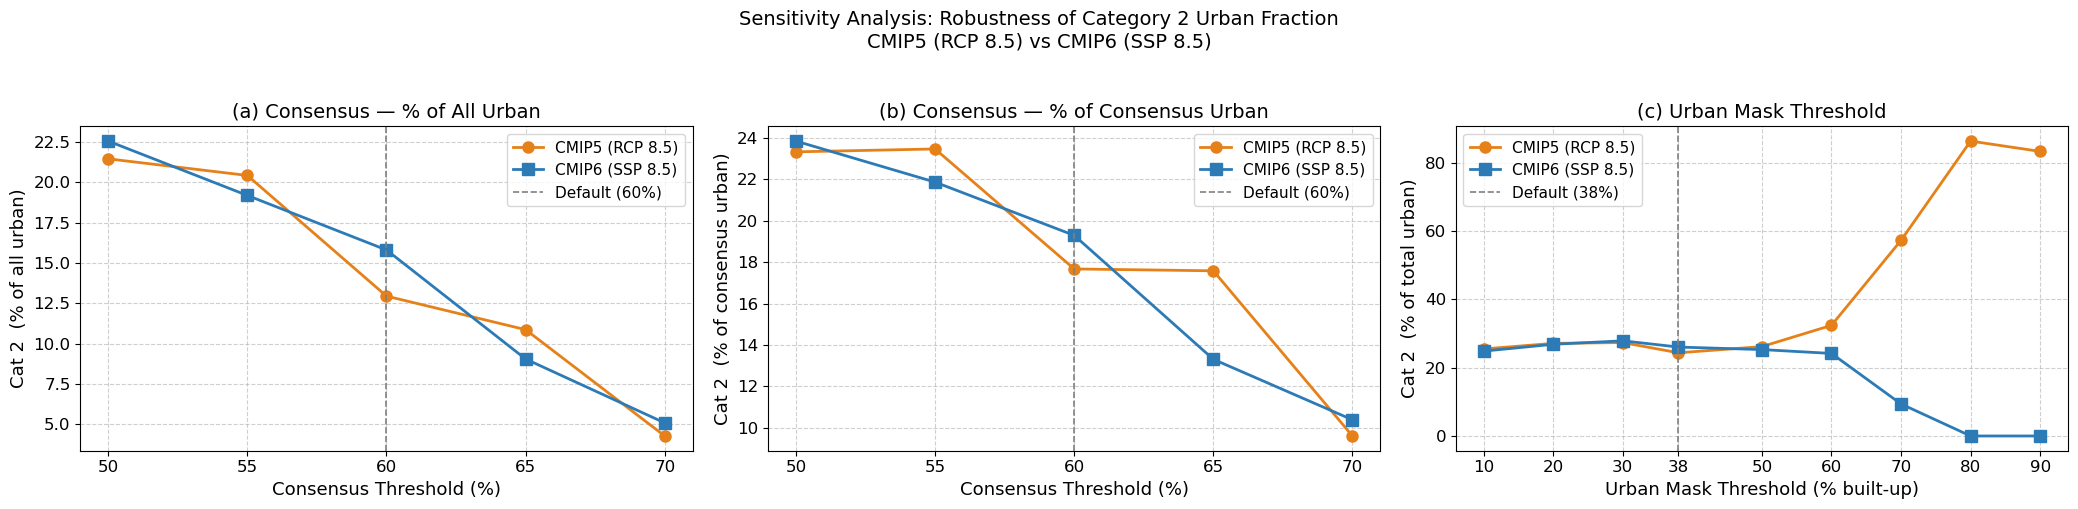

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# (a) consensus — % of all urban
ax = axes[0]
ax.plot(df_con_c5['Consensus Threshold (%)'], df_con_c5['Cat2 % of All Urban'],
        marker='o', linewidth=2, markersize=8, color='#e6811a', label='CMIP5 (RCP 8.5)')
ax.plot(df_con_c6['Consensus Threshold (%)'], df_con_c6['Cat2 % of All Urban'],
        marker='s', linewidth=2, markersize=8, color='#2c7bb6', label='CMIP6 (SSP 8.5)')
ax.axvline(x=60, color='gray', linestyle='--', linewidth=1.2, label='Default (60%)')
ax.set_xticks([int(t*100) for t in CONSENSUS_THRESHOLDS_SENSITIVITY])
ax.set_xlabel('Consensus Threshold (%)', fontsize=13)
ax.set_ylabel('Cat 2  (% of all urban)', fontsize=13)
ax.set_title('(a) Consensus — % of All Urban', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, linestyle='--', alpha=0.6)

# (b) consensus — % of consensus urban
ax = axes[1]
ax.plot(df_con_c5['Consensus Threshold (%)'], df_con_c5['Cat2 % of Consensus Urban'],
        marker='o', linewidth=2, markersize=8, color='#e6811a', label='CMIP5 (RCP 8.5)')
ax.plot(df_con_c6['Consensus Threshold (%)'], df_con_c6['Cat2 % of Consensus Urban'],
        marker='s', linewidth=2, markersize=8, color='#2c7bb6', label='CMIP6 (SSP 8.5)')
ax.axvline(x=60, color='gray', linestyle='--', linewidth=1.2, label='Default (60%)')
ax.set_xticks([int(t*100) for t in CONSENSUS_THRESHOLDS_SENSITIVITY])
ax.set_xlabel('Consensus Threshold (%)', fontsize=13)
ax.set_ylabel('Cat 2  (% of consensus urban)', fontsize=13)
ax.set_title('(b) Consensus — % of Consensus Urban', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, linestyle='--', alpha=0.6)

# (c) urban mask
ax = axes[2]
ax.plot(df_urb_c5['Urban Threshold (%)'], df_urb_c5['Cat2 % of Urban'],
        marker='o', linewidth=2, markersize=8, color='#e6811a', label='CMIP5 (RCP 8.5)')
ax.plot(df_urb_c6['Urban Threshold (%)'], df_urb_c6['Cat2 % of Urban'],
        marker='s', linewidth=2, markersize=8, color='#2c7bb6', label='CMIP6 (SSP 8.5)')
ax.axvline(x=URBAN_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Default ({URBAN_THRESHOLD}%)')
ax.set_xticks(URBAN_THRESHOLDS_SENSITIVITY)
ax.set_xlabel('Urban Mask Threshold (% built-up)', fontsize=13)
ax.set_ylabel('Cat 2  (% of total urban)', fontsize=13)
ax.set_title('(c) Urban Mask Threshold', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Sensitivity Analysis: Robustness of Category 2 Urban Fraction\n'
             'CMIP5 (RCP 8.5) vs CMIP6 (SSP 8.5)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
